## 1 & 2 - GET DATA THEN PREPROCESS
The dataset is a balanced set of good and  tires, around 1000 images each.

In [1]:
import torch
import torch.utils.data as util
from torchvision import transforms, datasets

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_ts_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder("/content/drive/MyDrive/_tires")
train, val, test = util.random_split(dataset, [1300, 370, 186], generator=torch.Generator().manual_seed(31))

train_loader = util.DataLoader(train, batch_size=32, shuffle=True)
val_loader = util.DataLoader(val, batch_size=32, shuffle=True)
test_loader = util.DataLoader(test, batch_size=32, shuffle=True)

train_loader.dataset.dataset.transform = train_transform
val_loader.dataset.dataset.transform = val_ts_transform
test_loader.dataset.dataset.transform = val_ts_transform

## 3 - TRAIN MODEL

In [2]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

for param in resnet50.parameters():
    param.requires_grad = False

NUM_OF_CLASSES = 2
num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_ftrs, NUM_OF_CLASSES)
resnet50 = resnet50.to(device)

optimizer = optim.SGD(resnet50.parameters(), lr=0.0001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


In [3]:
EPOCHS = 4

train_loss = []
train_accuracy = []
val_loss = []
val_accuracy = []

for epoch in range(EPOCHS):

    for i, batch in enumerate(train_loader):

        inputs, labels = (batch[0].to(device), batch[1].to(device))
        optimizer.zero_grad()

        outputs = resnet50(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())
        _, preds = torch.max(outputs, 1)
        accuracy = torch.sum(preds == labels.data).item() / len(labels)
        train_accuracy.append(accuracy)

        if i % 250 == 0:
            print(f"(TRAIN) EPOCH-{epoch} | ITER-{i} | LOSS-{round(loss.item(), 3)} | ACC-{round(accuracy, 3)}")

    resnet50.eval()
    for i, batch in enumerate(val_loader):

        inputs, labels = (batch[0].to(device), batch[1].to(device))

        outputs = resnet50(inputs)
        loss = criterion(outputs, labels)

        val_loss.append(loss.item())
        _, preds = torch.max(outputs, 1)
        accuracy = torch.sum(preds == labels.data).item() / len(labels)
        val_accuracy.append(accuracy)

        if i % 250 == 0:
            print(f"(VAL)   EPOCH-{epoch} | ITER-{i} | LOSS-{round(loss.item(), 3)} | ACC-{round(accuracy, 3)}")

(TRAIN) EPOCH-0 | ITER-0 | LOSS-0.72 | ACC-0.469
(VAL)   EPOCH-0 | ITER-0 | LOSS-0.652 | ACC-0.75
(TRAIN) EPOCH-1 | ITER-0 | LOSS-0.667 | ACC-0.625
(VAL)   EPOCH-1 | ITER-0 | LOSS-0.614 | ACC-0.75
(TRAIN) EPOCH-2 | ITER-0 | LOSS-0.598 | ACC-0.844
(VAL)   EPOCH-2 | ITER-0 | LOSS-0.582 | ACC-0.812
(TRAIN) EPOCH-3 | ITER-0 | LOSS-0.574 | ACC-0.781
(VAL)   EPOCH-3 | ITER-0 | LOSS-0.545 | ACC-0.875


## 4 - EVALUATE MODEL

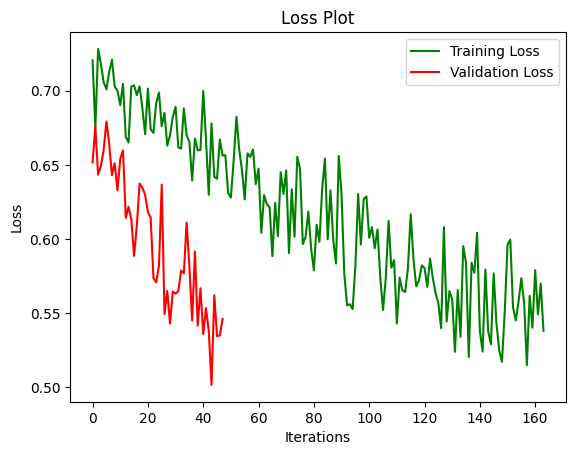

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_loss, color='green', label='Training Loss')
plt.plot(val_loss, color='red', label='Validation Loss')
plt.title('Loss Plot')
plt.xlabel('Iterations')
plt.ylabel('Loss')
_ = plt.legend()

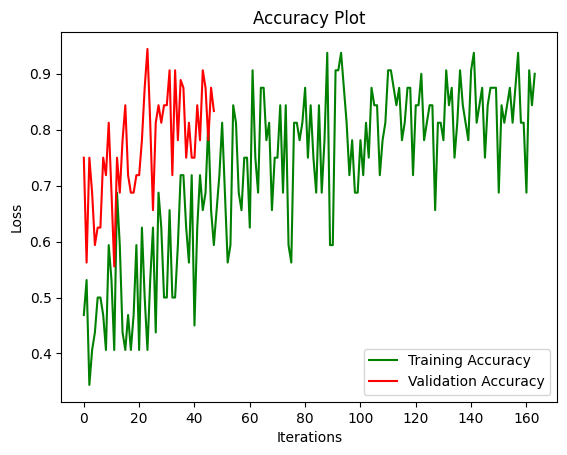

In [18]:
plt.figure()
plt.plot(train_accuracy, color='green', label='Training Accuracy')
plt.plot(val_accuracy, color='red', label='Validation Accuracy')
plt.title('Accuracy Plot')
plt.xlabel('Iterations')
plt.ylabel('Loss')
_ = plt.legend()

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_true = []
y_pred = []
for i, batch in enumerate(test_loader):

    inputs, labels = (batch[0].to(device), batch[1].to(device))
    y_true.extend(labels.detach().cpu().numpy())

    output = resnet50(inputs)
    _, preds = torch.max(output, 1)
    y_pred.extend(preds.detach().cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"ACCURACY IS:  {accuracy}")
print(f"PRECISION IS: {precision}")
print(f"RECALL IS:    {recall}")

ACCURACY IS:  0.8064516129032258
PRECISION IS: 0.8289473684210527
RECALL IS:    0.7325581395348837


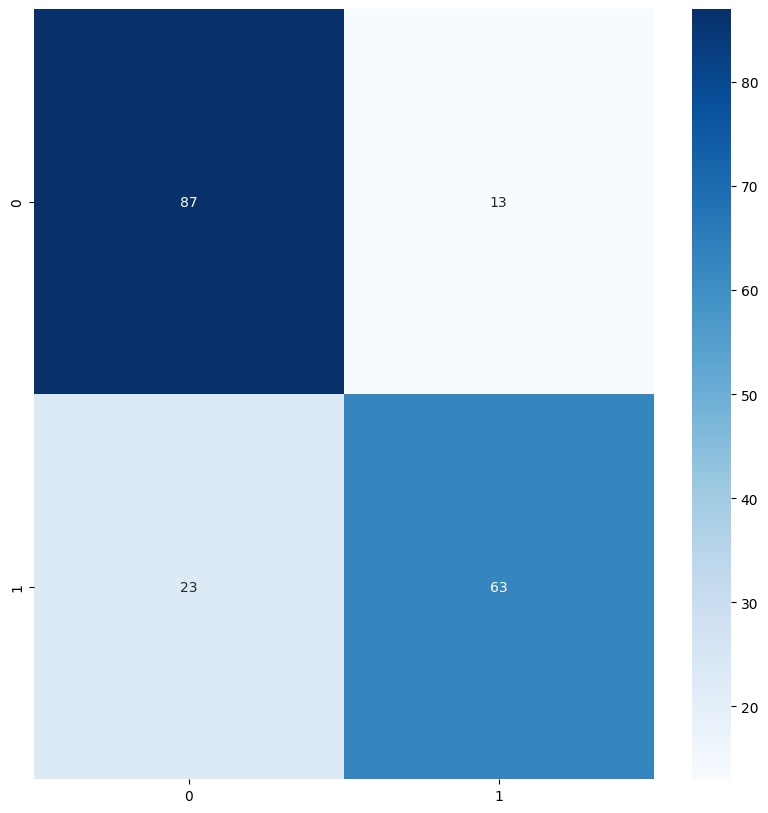

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,10))
_ = sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')